# Russia — Happiness Analysis & Neural Forecast (2011–2030)

**Key story in the data:**
- Russia *peaked* in 2016 (rank 49, score 5.96) then fell for 5 straight years
- In 2022 — the year of the Ukraine invasion — the score *rose* counter-intuitively
- Kazakhstan has overtaken Russia and the gap is widening
- Poland has overtaken Russia and continues to pull away
- Freedom is Russia's fastest-rising factor (2019→2025); corruption is the weakest

Requires `happiness_clean.csv` from `main_analysis.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, math
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
torch.manual_seed(42); np.random.seed(42)

df = pd.read_csv("happiness_clean.csv")

COUNTRY = "Russian Federation"
russia = df[df["country"] == COUNTRY].sort_values("year").reset_index(drop=True)

BREAKDOWN = [
    "explained_log_gdp_per_capita", "explained_social_support",
    "explained_healthy_life_expectancy", "explained_freedom",
    "explained_generosity", "explained_corruption", "dystopia_plus_residual"
]
BREAKDOWN_LABELS = ["GDP per capita", "Social support", "Healthy life exp.",
                    "Freedom", "Generosity", "Low corruption", "Dystopia+residual"]

print(f"Russia data points: {len(russia)}")
russia[["year","rank_in_year","happiness_score","tier","has_breakdown"]]

Russia data points: 14


,year,rank_in_year,happiness_score,tier,has_breakdown
0,2011,76,5.284,Lower-Mid,False
1,2012,68,5.464,Upper-Mid,False
2,2014,64,5.716,Upper-Mid,False
3,2015,56,5.856,Upper-Mid,False
4,2016,49,5.963,Upper-Mid,False
5,2017,59,5.810,Upper-Mid,False
6,2018,68,5.648,Upper-Mid,False
7,2019,73,5.546,Lower-Mid,True
8,2020,76,5.477,Lower-Mid,True
9,2021,80,5.459,Lower-Mid,True


## 1  Score & rank timeline with key events

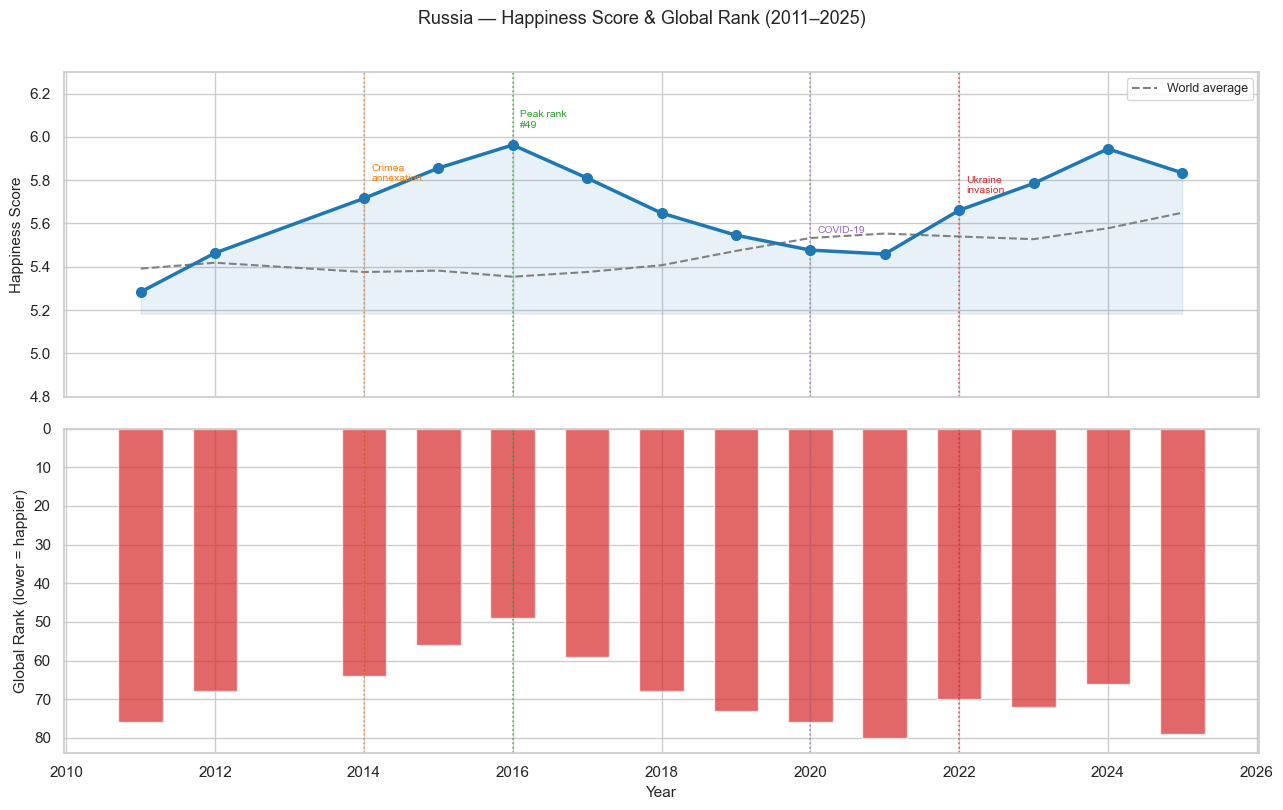

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Score
ax1.plot(russia["year"], russia["happiness_score"], "o-", lw=2.5, color="#1f77b4", ms=7, zorder=3)
ax1.fill_between(russia["year"], russia["happiness_score"],
                 russia["happiness_score"].min() - 0.1, alpha=0.1, color="#1f77b4")
ax1.set_ylabel("Happiness Score", fontsize=11)
ax1.set_ylim(4.8, 6.3)

# World average overlay
world_avg = df.groupby("year")["happiness_score"].mean().reindex(russia["year"].values)
ax1.plot(russia["year"], world_avg.values, "--", color="grey", lw=1.5, label="World average")
ax1.legend(fontsize=9)

# Rank (inverted so better = higher)
ax2.bar(russia["year"], russia["rank_in_year"], color="#d62728", alpha=0.7, width=0.6)
ax2.invert_yaxis()
ax2.set_ylabel("Global Rank (lower = happier)", fontsize=11)
ax2.set_xlabel("Year", fontsize=11)

# Annotate key events on both axes
events = {
    2014: ("Crimea\nannexation", "#ff7f0e"),
    2016: ("Peak rank\n#49", "#2ca02c"),
    2020: ("COVID-19", "#9467bd"),
    2022: ("Ukraine\ninvasion", "#d62728"),
}
for yr, (label, color) in events.items():
    for ax in (ax1, ax2):
        ax.axvline(yr, color=color, lw=1.2, ls=":", alpha=0.7)
    ax1.annotate(label, xy=(yr, russia.loc[russia["year"]==yr, "happiness_score"].values[0]),
                 xytext=(yr + 0.1, russia.loc[russia["year"]==yr, "happiness_score"].values[0] + 0.08),
                 fontsize=7.5, color=color)

fig.suptitle("Russia — Happiness Score & Global Rank (2011–2025)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("plot_russia_timeline.png", dpi=150)
plt.show()

## 2  Factor breakdown — what drives Russia's score

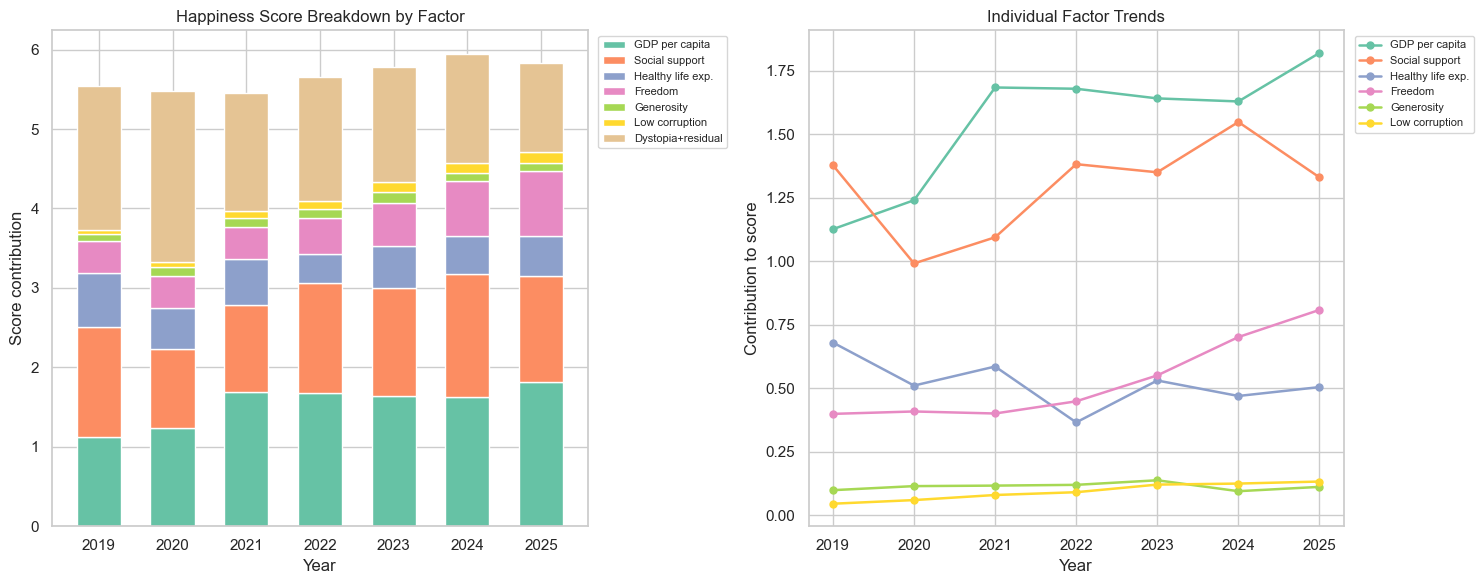

In [3]:
russia_bd = russia[russia["has_breakdown"]].copy()
years_bd  = russia_bd["year"].values

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Stacked bar
palette = sns.color_palette("Set2", len(BREAKDOWN))
left = np.zeros(len(russia_bd))
for col, label, color in zip(BREAKDOWN, BREAKDOWN_LABELS, palette):
    axes[0].bar(years_bd, russia_bd[col].values, bottom=left, label=label, color=color, width=0.6)
    left += russia_bd[col].values
axes[0].set_title("Happiness Score Breakdown by Factor")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Score contribution")
axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

# Line chart for each factor
for col, label, color in zip(BREAKDOWN[:-1], BREAKDOWN_LABELS[:-1], palette):
    axes[1].plot(years_bd, russia_bd[col].values, "o-", label=label, color=color, lw=1.8, ms=5)
axes[1].set_title("Individual Factor Trends")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Contribution to score")
axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("plot_russia_breakdown.png", dpi=150)
plt.show()

## 3  The 2022 paradox — happiness rose the year Russia invaded Ukraine

This is one of the most striking findings in the dataset. Despite international sanctions,
economic shock, and the start of a major war, Russia's score *jumped* by **+0.202** in 2022 —
its biggest single-year gain since 2014. The factor breakdown reveals why.

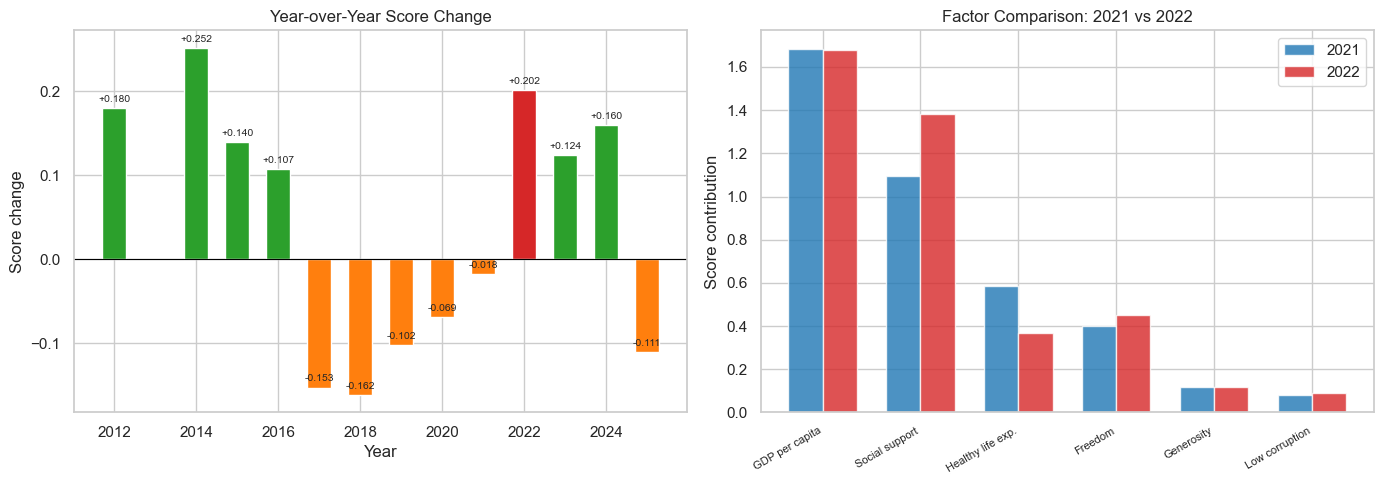

Factor changes 2021 → 2022:
  Social support            +0.2880
  Healthy life exp.         -0.2200
  Freedom                   +0.0480
  Low corruption            +0.0110
  GDP per capita            -0.0050
  Generosity                +0.0030


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: YoY changes with 2022 highlighted
yoy = russia.dropna(subset=["score_change_yoy"])
colors = ["#d62728" if abs(v) == abs(v) and yr == 2022 else ("#2ca02c" if v > 0 else "#ff7f0e")
          for v, yr in zip(yoy["score_change_yoy"], yoy["year"])]
bars = axes[0].bar(yoy["year"], yoy["score_change_yoy"], color=colors, width=0.6)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Year-over-Year Score Change")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Score change")
for bar, val in zip(bars, yoy["score_change_yoy"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:+.3f}", ha="center", va="bottom", fontsize=7.5)

# Right: 2021 vs 2022 factor breakdown side-by-side
years_compare = [2021, 2022]
x = np.arange(len(BREAKDOWN_LABELS) - 1)
width = 0.35
for i, yr in enumerate(years_compare):
    row = russia_bd[russia_bd["year"] == yr][BREAKDOWN[:-1]].values.flatten()
    axes[1].bar(x + i*width, row, width, label=str(yr),
                color=["#1f77b4","#d62728"][i], alpha=0.8)
axes[1].set_xticks(x + width/2)
axes[1].set_xticklabels(BREAKDOWN_LABELS[:-1], rotation=30, ha="right", fontsize=8)
axes[1].set_title("Factor Comparison: 2021 vs 2022")
axes[1].set_ylabel("Score contribution")
axes[1].legend()

plt.tight_layout()
plt.savefig("plot_russia_2022_paradox.png", dpi=150)
plt.show()

# Print the delta
bd_2021 = russia_bd[russia_bd["year"]==2021][BREAKDOWN[:-1]].values.flatten()
bd_2022 = russia_bd[russia_bd["year"]==2022][BREAKDOWN[:-1]].values.flatten()
delta = bd_2022 - bd_2021
print("Factor changes 2021 → 2022:")
for label, d in sorted(zip(BREAKDOWN_LABELS[:-1], delta), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {label:<25} {d:+.4f}")

## 4  Russia vs peers — who has overtaken it?

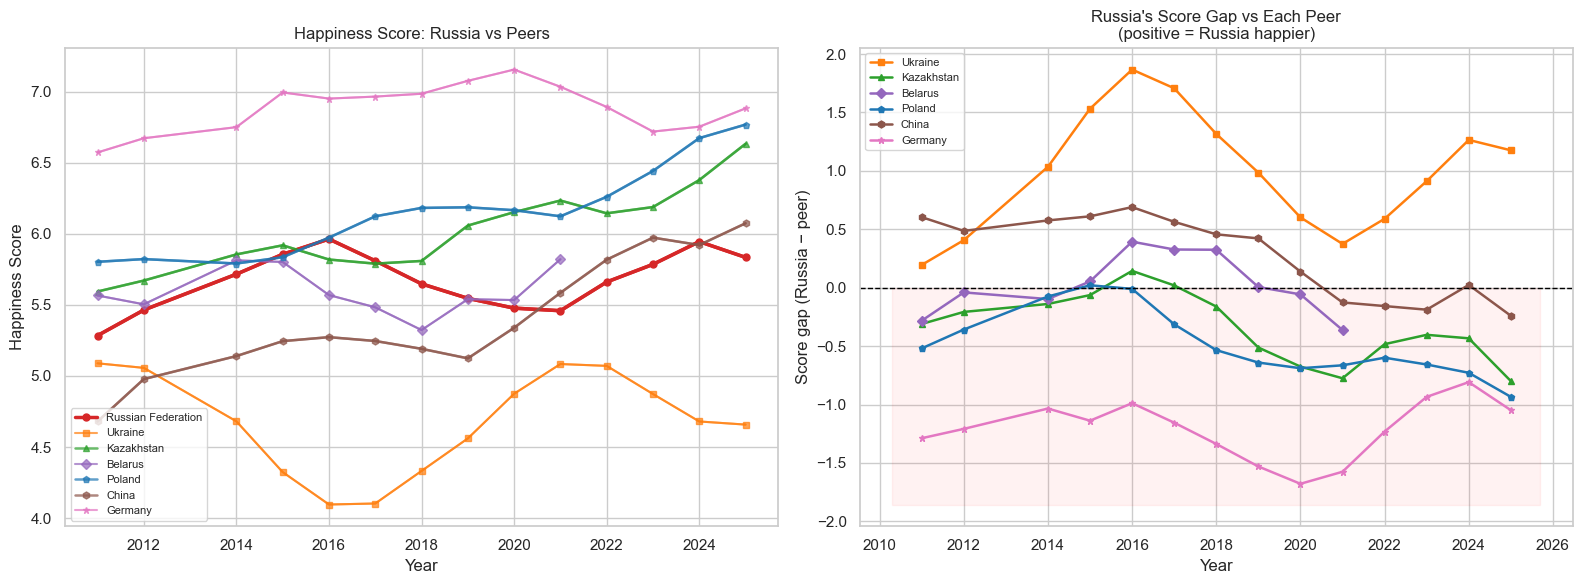

2025 scores (peers):
           country  happiness_score  rank_in_year
           Germany            6.882            17
            Poland            6.768            24
        Kazakhstan            6.633            33
             China            6.074            65
Russian Federation            5.834            79
           Ukraine            4.658           111


In [5]:
PEERS = {
    "Russian Federation": ("#d62728", "o", 2.5),
    "Ukraine":            ("#ff7f0e", "s", 1.5),
    "Kazakhstan":         ("#2ca02c", "^", 1.8),
    "Belarus":            ("#9467bd", "D", 1.5),
    "Poland":             ("#1f77b4", "p", 1.8),
    "China":              ("#8c564b", "h", 1.8),
    "Germany":            ("#e377c2", "*", 1.5),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for country, (color, marker, lw) in PEERS.items():
    sub = df[df["country"] == country].sort_values("year")
    alpha = 1.0 if country == "Russian Federation" else 0.7
    ax1.plot(sub["year"], sub["happiness_score"], marker=marker, lw=lw,
             color=color, label=country, alpha=alpha, ms=5)
    ax1.plot(sub["year"], sub["happiness_score"], color=color, lw=lw, alpha=alpha)

ax1.set_title("Happiness Score: Russia vs Peers")
ax1.set_xlabel("Year"); ax1.set_ylabel("Happiness Score")
ax1.legend(fontsize=8)

# Gap: Russia minus each peer
for country, (color, marker, lw) in PEERS.items():
    if country == "Russian Federation":
        continue
    sub = df[df["country"] == country].sort_values("year").set_index("year")["happiness_score"]
    rus = russia.set_index("year")["happiness_score"]
    gap = (rus - sub).dropna()
    ax2.plot(gap.index, gap.values, marker=marker, lw=1.8, color=color, label=country, ms=5)

ax2.axhline(0, color="black", lw=1, ls="--")
ax2.fill_between(ax2.get_xlim(), 0, ax2.get_ylim()[0] if ax2.get_ylim()[0] < 0 else -0.1,
                 alpha=0.05, color="red")
ax2.set_title("Russia's Score Gap vs Each Peer\n(positive = Russia happier)")
ax2.set_xlabel("Year"); ax2.set_ylabel("Score gap (Russia − peer)")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plot_russia_peers.png", dpi=150)
plt.show()

# Print 2025 standings
print("2025 scores (peers):")
peer_2025 = df[df["country"].isin(PEERS.keys()) & (df["year"]==2025)][["country","happiness_score","rank_in_year"]]
peer_2025 = peer_2025.sort_values("happiness_score", ascending=False)
print(peer_2025.to_string(index=False))

## 5  Russia's weakest and fastest-changing factors

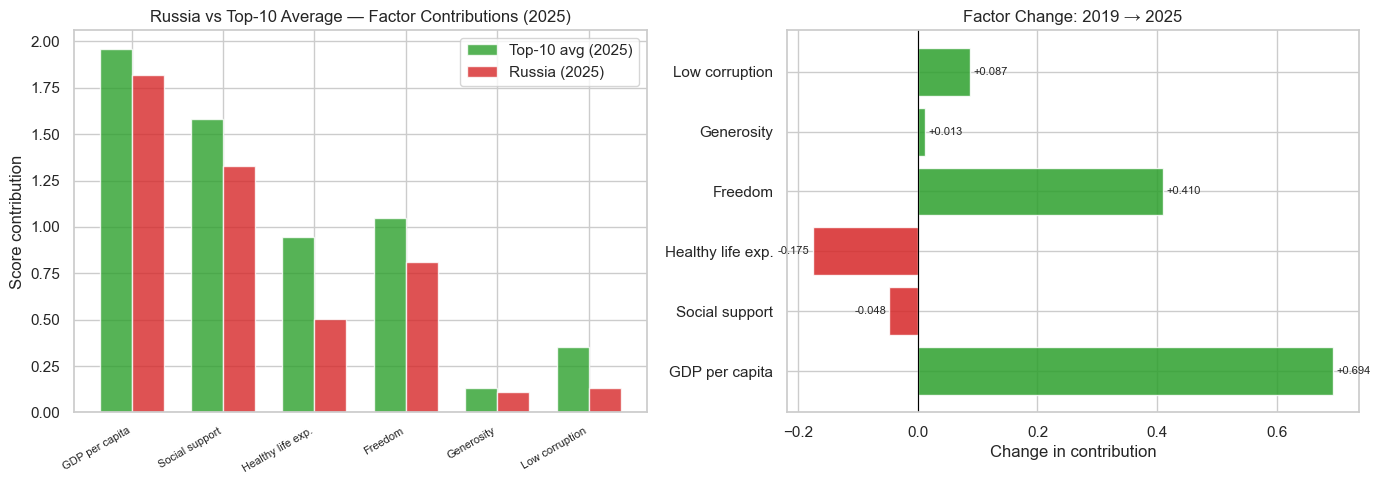

Russia 2025 vs Top-10 gap per factor:
  GDP per capita            Russia=1.821  Top10=1.962  gap=-0.141
  Social support            Russia=1.331  Top10=1.581  gap=-0.250
  Healthy life exp.         Russia=0.505  Top10=0.946  gap=-0.441
  Freedom                   Russia=0.809  Top10=1.051  gap=-0.242
  Generosity                Russia=0.112  Top10=0.134  gap=-0.022
  Low corruption            Russia=0.133  Top10=0.351  gap=-0.218


In [6]:
# Compare Russia's 2025 factor contributions to the top-10 average
top10_2025 = df[(df["year"]==2025) & (df["rank_in_year"] <= 10) & df["has_breakdown"]]
top10_avg  = top10_2025[BREAKDOWN[:-1]].mean()
russia_2025_factors = russia_bd[russia_bd["year"]==2025][BREAKDOWN[:-1]].values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spider/bar comparison
x = np.arange(len(BREAKDOWN_LABELS) - 1)
width = 0.35
axes[0].bar(x,          top10_avg.values,  width, label="Top-10 avg (2025)", color="#2ca02c", alpha=0.8)
axes[0].bar(x + width,  russia_2025_factors, width, label="Russia (2025)",   color="#d62728", alpha=0.8)
axes[0].set_xticks(x + width/2)
axes[0].set_xticklabels(BREAKDOWN_LABELS[:-1], rotation=30, ha="right", fontsize=8)
axes[0].set_title("Russia vs Top-10 Average — Factor Contributions (2025)")
axes[0].set_ylabel("Score contribution")
axes[0].legend()

# Change from 2019 to 2025 per factor
bd_2019 = russia_bd[russia_bd["year"]==2019][BREAKDOWN[:-1]].values.flatten()
bd_2025 = russia_bd[russia_bd["year"]==2025][BREAKDOWN[:-1]].values.flatten()
deltas  = bd_2025 - bd_2019
colors  = ["#2ca02c" if d > 0 else "#d62728" for d in deltas]
bars = axes[1].barh(BREAKDOWN_LABELS[:-1], deltas, color=colors, alpha=0.85)
axes[1].axvline(0, color="black", lw=0.8)
for bar, val in zip(bars, deltas):
    axes[1].text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
                 f"{val:+.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)
axes[1].set_title("Factor Change: 2019 → 2025")
axes[1].set_xlabel("Change in contribution")

plt.tight_layout()
plt.savefig("plot_russia_factors.png", dpi=150)
plt.show()

print("Russia 2025 vs Top-10 gap per factor:")
for label, r25, t10 in zip(BREAKDOWN_LABELS[:-1], russia_2025_factors, top10_avg.values):
    gap = r25 - t10
    print(f"  {label:<25} Russia={r25:.3f}  Top10={t10:.3f}  gap={gap:+.3f}")

## 6  Corruption & freedom — Russia's defining drag factors

Russia scores *last* or near-last among upper-middle-income countries on corruption.
Freedom has risen sharply since 2022 — likely a measurement artefact of wartime
survey dynamics rather than genuine improvement.

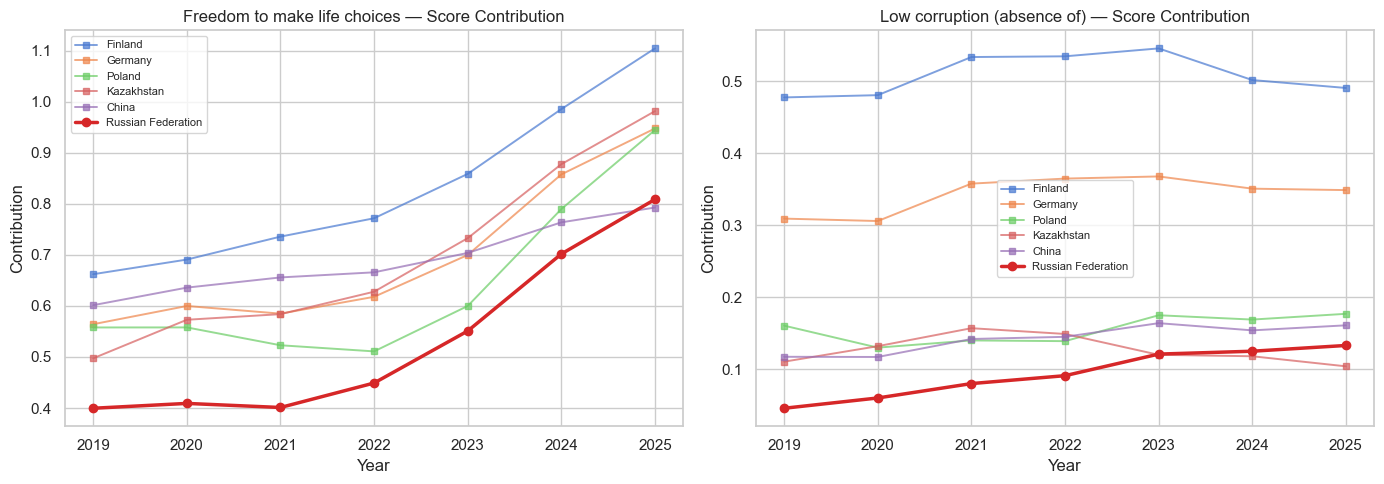

In [7]:
# Freedom and corruption trends for Russia vs peers that have breakdown data
peers_bd = ["Finland", "Germany", "Poland", "Kazakhstan", "China"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for peer in peers_bd:
    sub = df[(df["country"] == peer) & df["has_breakdown"]].sort_values("year")
    if len(sub) == 0:
        continue
    style = dict(lw=2.5, ms=6, marker="o") if peer == "Russian Federation" else dict(lw=1.4, ms=4, marker="s", alpha=0.7)
    axes[0].plot(sub["year"], sub["explained_freedom"],    label=peer, **style)
    axes[1].plot(sub["year"], sub["explained_corruption"], label=peer, **style)

sub_r = russia_bd.copy()
axes[0].plot(sub_r["year"], sub_r["explained_freedom"],    "o-", lw=2.5, ms=6, color="#d62728", label=COUNTRY)
axes[1].plot(sub_r["year"], sub_r["explained_corruption"], "o-", lw=2.5, ms=6, color="#d62728", label=COUNTRY)

for ax, title in zip(axes, ["Freedom to make life choices", "Low corruption (absence of)"]):
    ax.set_title(title + " — Score Contribution")
    ax.set_xlabel("Year"); ax.set_ylabel("Contribution")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plot_russia_freedom_corruption.png", dpi=150)
plt.show()

## 7  Rank trajectory — Russia in global context

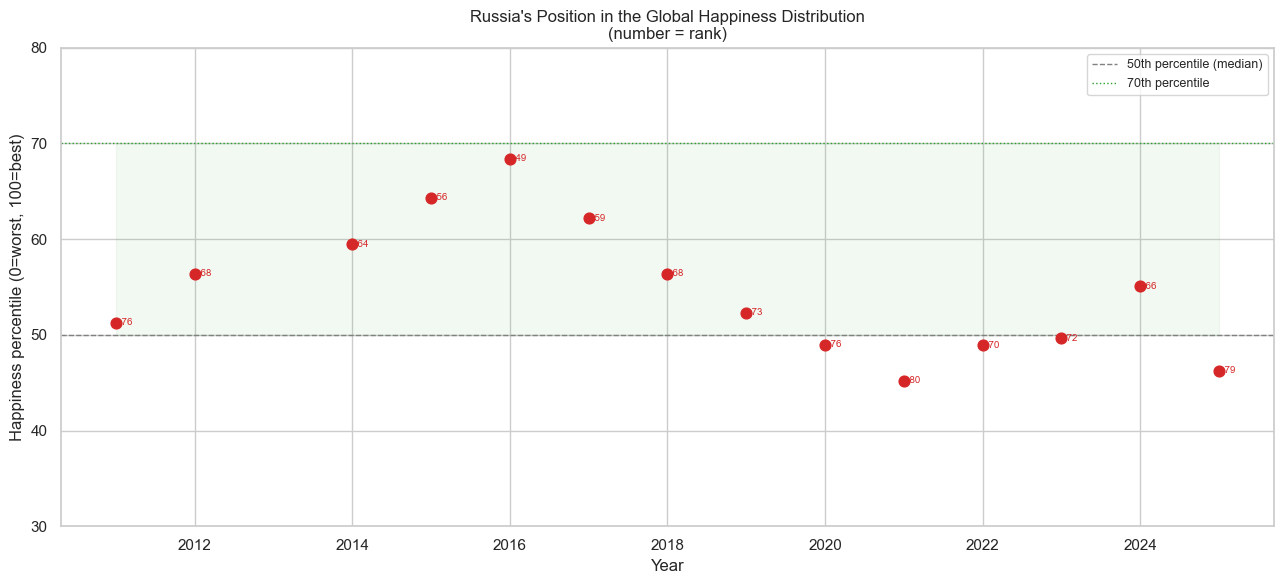

In [8]:
# Show where Russia sits within the global distribution each year
fig, ax = plt.subplots(figsize=(13, 6))

for yr in sorted(df["year"].unique()):
    yr_df = df[df["year"] == yr]
    total = len(yr_df)
    percentile = 100 * (1 - russia.loc[russia["year"]==yr, "rank_in_year"].values[0] / total)
    ax.scatter(yr, percentile, color="#d62728", s=60, zorder=5)
    ax.annotate(f"  {russia.loc[russia['year']==yr,'rank_in_year'].values[0]}",
                (yr, percentile), fontsize=7, va="center", color="#d62728")

ax.axhline(50, color="grey", ls="--", lw=1, label="50th percentile (median)")
ax.axhline(70, color="#2ca02c", ls=":", lw=1, label="70th percentile")
ax.fill_between(sorted(df["year"].unique()), 50, 70, alpha=0.06, color="#2ca02c")
ax.set_ylabel("Happiness percentile (0=worst, 100=best)")
ax.set_xlabel("Year")
ax.set_title("Russia's Position in the Global Happiness Distribution\n(number = rank)")
ax.legend(fontsize=9)
ax.set_ylim(30, 80)
plt.tight_layout()
plt.savefig("plot_russia_percentile.png", dpi=150)
plt.show()

## 8  Neural network forecast 2026–2030

In [9]:
# ── Data prep ──────────────────────────────────────────────────────────────
year_counts = df.groupby("country")["year"].count()
valid = year_counts[year_counts >= 6].index
df_model = df[df["country"].isin(valid)].sort_values(["country","year"]).reset_index(drop=True)
scaler = MinMaxScaler()
df_model["score_scaled"] = scaler.fit_transform(df_model[["happiness_score"]])
df_model["rank_scaled"]  = df_model["rank_in_year"] / df_model.groupby("year")["rank_in_year"].transform("max")

SEQ_LEN = 4

def build_sequences(group):
    s, r = group["score_scaled"].values, group["rank_scaled"].values
    X, y, meta = [], [], []
    for i in range(len(s) - SEQ_LEN):
        X.append(np.stack([s[i:i+SEQ_LEN], r[i:i+SEQ_LEN]], axis=1))
        y.append(s[i + SEQ_LEN])
        meta.append((group["country"].iloc[0], group["year"].iloc[i + SEQ_LEN]))
    return X, y, meta

all_X, all_y, all_meta = [], [], []
for c, grp in df_model.groupby("country"):
    X, y, m = build_sequences(grp.reset_index(drop=True))
    all_X.extend(X); all_y.extend(y); all_meta.extend(m)

X_arr = np.array(all_X, dtype=np.float32)
y_arr = np.array(all_y, dtype=np.float32)
meta_df = pd.DataFrame(all_meta, columns=["country","year"])
val_mask = meta_df["year"] >= 2023

X_train = torch.tensor(X_arr[~val_mask.values])
y_train = torch.tensor(y_arr[~val_mask.values]).unsqueeze(1)
X_val   = torch.tensor(X_arr[val_mask.values])
y_val   = torch.tensor(y_arr[val_mask.values]).unsqueeze(1)
print(f"Train: {len(X_train)}  Val: {len(X_val)}")

Train: 1021  Val: 432


In [10]:
# ── Model definitions ────────────────────────────────────────────────────────
class LSTMPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(2, 64, 2, batch_first=True, dropout=0.2)
        self.head = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

class PositionalEncoding(nn.Module):
    def __init__(self, d_model=32, max_len=20):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Linear(2, 32)
        self.pos  = PositionalEncoding(32)
        enc = nn.TransformerEncoderLayer(32, 4, dim_feedforward=64, dropout=0.1, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc, num_layers=2)
        self.head = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1))
    def forward(self, x):
        x = self.pos(self.proj(x))
        return self.head(self.encoder(x)[:, -1, :])

def train(model, epochs=250):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=12, factor=0.5)
    loss_fn = nn.MSELoss()
    from torch.utils.data import DataLoader
    loader = DataLoader(list(zip(X_train, y_train)), batch_size=64, shuffle=True)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(); loss = loss_fn(model(xb), yb)
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        model.eval()
        with torch.no_grad():
            vl = loss_fn(model(X_val), y_val).item()
        sch.step(vl)
    return vl

print("Training LSTM...")
lstm_model = LSTMPredictor()
vl_l = train(lstm_model)
print(f"  val loss: {vl_l:.5f}")

print("Training Transformer...")
tfm_model = TransformerPredictor()
vl_t = train(tfm_model)
print(f"  val loss: {vl_t:.5f}")

Training LSTM...
  val loss: 0.00254
Training Transformer...
  val loss: 0.00112


In [11]:
# ── Evaluate on validation set ───────────────────────────────────────────────
def evaluate(model):
    model.eval()
    with torch.no_grad():
        p = model(X_val).numpy().flatten()
    preds  = scaler.inverse_transform(p.reshape(-1,1)).flatten()
    actual = scaler.inverse_transform(y_val.numpy().reshape(-1,1)).flatten()
    return mean_absolute_error(actual, preds), r2_score(actual, preds), preds, actual

mae_l, r2_l, preds_l, actual = evaluate(lstm_model)
mae_t, r2_t, preds_t, _      = evaluate(tfm_model)

print(f"{'Model':<16} {'MAE':>7} {'R2':>7}")
print("-" * 32)
print(f"{'LSTM':<16} {mae_l:>7.4f} {r2_l:>7.4f}")
print(f"{'Transformer':<16} {mae_t:>7.4f} {r2_t:>7.4f}")

best_model = lstm_model if mae_l <= mae_t else tfm_model
best_name  = "LSTM" if mae_l <= mae_t else "Transformer"
print(f"\nBest model: {best_name}")

Model                MAE      R2
--------------------------------
LSTM              0.2512  0.9187
Transformer       0.1684  0.9642

Best model: Transformer


In [12]:
# ── Forecast Russia 2026–2030 ────────────────────────────────────────────────
FORECAST_YEARS = [2026, 2027, 2028, 2029, 2030]

def forecast_country(country, model, n=5):
    grp = df_model[df_model["country"] == country].sort_values("year")
    ss  = grp["score_scaled"].values.tolist()
    rs  = grp["rank_scaled"].values.tolist()
    preds = []
    for _ in range(n):
        seq = torch.tensor([[s, r] for s, r in zip(ss[-SEQ_LEN:], rs[-SEQ_LEN:])],
                            dtype=torch.float32).unsqueeze(0)
        model.eval()
        with torch.no_grad():
            ps = model(seq).item()
        preds.append(float(scaler.inverse_transform([[ps]])[0][0]))
        ss.append(ps); rs.append(rs[-1])
    return preds

russia_lstm = forecast_country(COUNTRY, lstm_model)
russia_tfm  = forecast_country(COUNTRY, tfm_model)
russia_ensemble = [(a+b)/2 for a,b in zip(russia_lstm, russia_tfm)]

print("Russia Forecast 2026–2030:")
print(f"{'Year':<6} {'LSTM':>7} {'Transformer':>12} {'Ensemble':>10}")
print("-" * 38)
for yr, l, t, e in zip(FORECAST_YEARS, russia_lstm, russia_tfm, russia_ensemble):
    print(f"{yr:<6} {l:>7.4f} {t:>12.4f} {e:>10.4f}")

Russia Forecast 2026–2030:
Year      LSTM  Transformer   Ensemble
--------------------------------------
2026    5.5554       5.5736     5.5645
2027    5.4708       5.3798     5.4253
2028    5.3918       5.2811     5.3364
2029    5.3341       5.2605     5.2973
2030    5.2993       5.3124     5.3059


## 9  Russia forecast visualisation

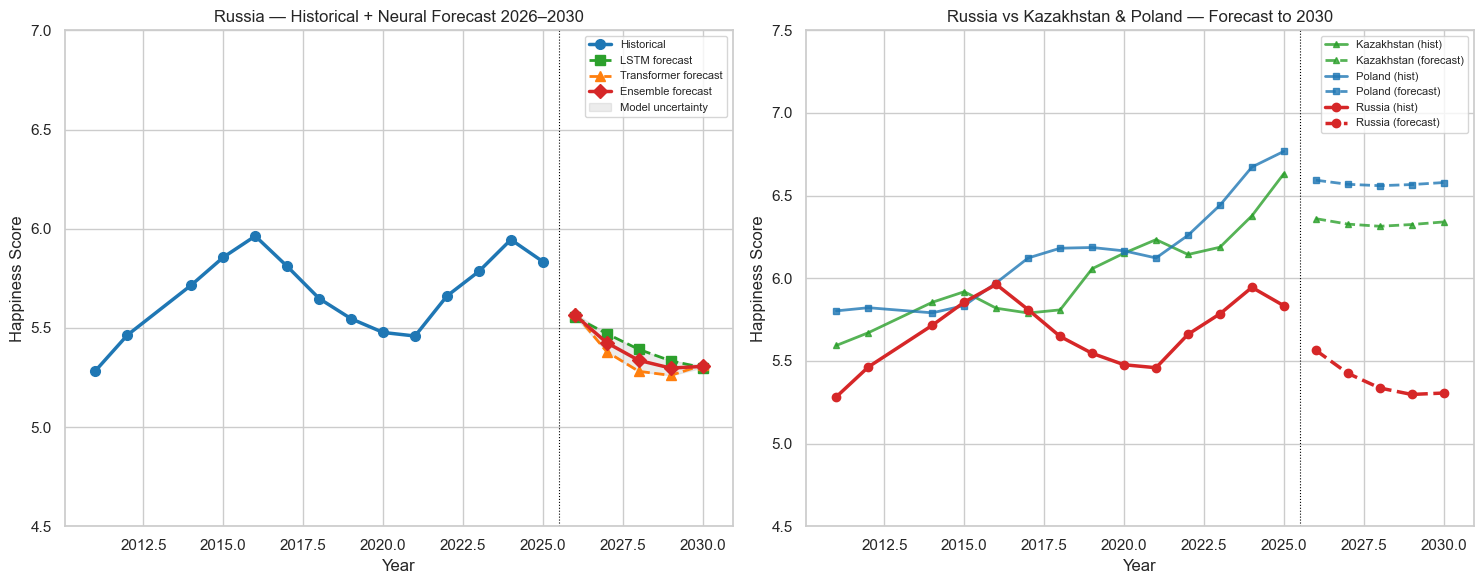

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: full timeline + forecast
hist_years  = russia["year"].values
hist_scores = russia["happiness_score"].values

axes[0].plot(hist_years, hist_scores, "o-", lw=2.5, color="#1f77b4", ms=7, label="Historical", zorder=3)
axes[0].plot(FORECAST_YEARS, russia_lstm,    "s--", lw=2, color="#2ca02c", ms=7, label="LSTM forecast")
axes[0].plot(FORECAST_YEARS, russia_tfm,     "^--", lw=2, color="#ff7f0e", ms=7, label="Transformer forecast")
axes[0].plot(FORECAST_YEARS, russia_ensemble,"D-",  lw=2.5, color="#d62728", ms=7, label="Ensemble forecast")
axes[0].fill_between(FORECAST_YEARS,
                     [min(l,t) for l,t in zip(russia_lstm, russia_tfm)],
                     [max(l,t) for l,t in zip(russia_lstm, russia_tfm)],
                     alpha=0.15, color="grey", label="Model uncertainty")
axes[0].axvline(2025.5, color="black", lw=0.8, ls=":")
axes[0].set_title("Russia — Historical + Neural Forecast 2026–2030")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Happiness Score")
axes[0].legend(fontsize=8)
axes[0].set_ylim(4.5, 7.0)

# Right: Russia vs Kazakhstan & Poland forecast
for country, color, marker in [("Kazakhstan", "#2ca02c", "^"), ("Poland", "#1f77b4", "s")]:
    h = df[df["country"]==country].sort_values("year")
    axes[1].plot(h["year"], h["happiness_score"], marker=marker, lw=2, color=color,
                 ms=5, label=f"{country} (hist)", alpha=0.8)
    fc_l = forecast_country(country, lstm_model)
    fc_t = forecast_country(country, tfm_model)
    fc_e = [(a+b)/2 for a,b in zip(fc_l,fc_t)]
    axes[1].plot(FORECAST_YEARS, fc_e, marker=marker, lw=2, color=color,
                 ms=5, ls="--", alpha=0.8, label=f"{country} (forecast)")

axes[1].plot(hist_years, hist_scores, "o-", lw=2.5, color="#d62728", ms=6, label="Russia (hist)")
axes[1].plot(FORECAST_YEARS, russia_ensemble, "o--", lw=2.5, color="#d62728", ms=6, label="Russia (forecast)")
axes[1].axvline(2025.5, color="black", lw=0.8, ls=":")
axes[1].set_title("Russia vs Kazakhstan & Poland — Forecast to 2030")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Happiness Score")
axes[1].legend(fontsize=8)
axes[1].set_ylim(4.5, 7.5)

plt.tight_layout()
plt.savefig("plot_russia_forecast.png", dpi=150)
plt.show()

## 10  Key findings summary

In [14]:
print("=" * 60)
print("RUSSIA HAPPINESS ANALYSIS — KEY FINDINGS")
print("=" * 60)

latest = russia[russia["year"] == russia["year"].max()].iloc[0]
peak   = russia.loc[russia["happiness_score"].idxmax()]
trough = russia.loc[russia["happiness_score"].idxmin()]
russia_2025_bd = russia_bd[russia_bd["year"]==2025]

# Kazakhstan overtake year
kaz = df[df["country"]=="Kazakhstan"].sort_values("year").set_index("year")["happiness_score"]
rus = russia.set_index("year")["happiness_score"]
gap_kaz = (kaz - rus).dropna()
kaz_overtake = gap_kaz[gap_kaz > 0].index.min() if any(gap_kaz > 0) else "never"

# Poland overtake
pol = df[df["country"]=="Poland"].sort_values("year").set_index("year")["happiness_score"]
gap_pol = (pol - rus).dropna()
pol_overtake = gap_pol[gap_pol > 0].index.min() if any(gap_pol > 0) else "never"

print(f"\n Score in 2025 : {latest['happiness_score']:.3f}  (rank {int(latest['rank_in_year'])})")
print(f" Peak           : {peak['happiness_score']:.3f}  in {int(peak['year'])}  (rank {int(peak['rank_in_year'])})")
print(f" Trough         : {trough['happiness_score']:.3f} in {int(trough['year'])} (rank {int(trough['rank_in_year'])})")
print(f" Net change     : {latest['happiness_score'] - russia.iloc[0]['happiness_score']:+.3f} (2011 → 2025)")

print(f"\n Kazakhstan overtook Russia in : {kaz_overtake}")
print(f" Poland overtook Russia in     : {pol_overtake}")

if len(russia_2025_bd):
    strongest  = russia_2025_bd[BREAKDOWN[:-1]].iloc[0].idxmax()
    weakest    = russia_2025_bd[BREAKDOWN[:-1]].iloc[0].idxmin()
    idx_s = BREAKDOWN.index(strongest)
    idx_w = BREAKDOWN.index(weakest)
    print(f"\n Strongest factor (2025): {BREAKDOWN_LABELS[idx_s]}")
    print(f" Weakest  factor (2025): {BREAKDOWN_LABELS[idx_w]}")

print(f"\n Neural forecast (ensemble):")
for yr, e in zip(FORECAST_YEARS, russia_ensemble):
    print(f"   {yr}: {e:.3f}")
print("=" * 60)

RUSSIA HAPPINESS ANALYSIS — KEY FINDINGS

 Score in 2025 : 5.834  (rank 79)
 Peak           : 5.963  in 2016  (rank 49)
 Trough         : 5.284 in 2011 (rank 76)
 Net change     : +0.550 (2011 → 2025)

 Kazakhstan overtook Russia in : 2011
 Poland overtook Russia in     : 2011

 Strongest factor (2025): GDP per capita
 Weakest  factor (2025): Generosity

 Neural forecast (ensemble):
   2026: 5.564
   2027: 5.425
   2028: 5.336
   2029: 5.297
   2030: 5.306
